**Geneformer, Anndata, Loom**

In [1]:
!git lfs install
!git clone https://huggingface.co/ctheodoris/Geneformer
!cd Geneformer # Note: 'cd' in a notebook cell only changes the directory for that cell
!pip install .

Git LFS initialized.
fatal: destination path 'Geneformer' already exists and is not an empty directory.
ERROR: Directory '.' is not installable. Neither 'setup.py' nor 'pyproject.toml' found.


In [2]:
# inspiration from : https://wang-lab.hkust.edu.hk/others/Tutorials/geneformer/seuToAnn.html
# !pip install gdrive

In [3]:
!pip install scanpy
!pip install loompy

In [4]:
# Install R if not already available
!apt-get update
!apt-get install -y r-base r-base-dev

!Rscript -e "install.packages(c('Seurat', 'devtools', 'remotes'), repos='https://cran.rstudio.com/')"

!Rscript -e "devtools::install_github('mojaveazure/seurat-disk')"
!Rscript -e "remotes::install_github('mojaveazure/seurat-disk')"

!Rscript -e "devtools::install_github('satijalab/seurat-data')"
!Rscript -e "install.packages('SeuratData', repos='https://cran.rstudio.com/')"

# Verify installation
!Rscript -e "library(Seurat); library(SeuratDisk); library(SeuratData); print('✅ Packages installed successfully!')"

Streaming output truncated to the last 5000 lines.
      |                              ^~~~~~~~~~~~~~~~
/usr/local/lib/R/site-library/RcppEigen/include/Eigen/src/Core/DenseCoeffsBase.h: In instantiation of ‘class Eigen::DenseCoeffsBase<Eigen::Transpose<const Eigen::Block<const Eigen::Map<const Eigen::Matrix<double, -1, -1> >, 1, -1, false> >, 0>’:
/usr/local/lib/R/site-library/RcppEigen/include/Eigen/src/Core/DenseCoeffsBase.h:481:7:   required from ‘class Eigen::DenseCoeffsBase<Eigen::Transpose<const Eigen::Block<const Eigen::Map<const Eigen::Matrix<double, -1, -1> >, 1, -1, false> >, 2>’
/usr/local/lib/R/site-library/RcppEigen/include/Eigen/src/Core/DenseBase.h:41:34:   required from ‘class Eigen::DenseBase<Eigen::Transpose<const Eigen::Block<const Eigen::Map<const Eigen::Matrix<double, -1, -1> >, 1, -1, false> > >’
/usr/local/lib/R/site-library/RcppEigen/include/Eigen/src/Core/MatrixBase.h:48:34:   required from ‘class Eigen::MatrixBase<Eigen::Transpose<const Eigen::Block<const Eig

  0%|          | 0.00/23.5M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2638 × 1838
    obs: 'n_genes', 'percent_mito', 'n_counts', 'louvain'
    var: 'n_cells'
    uns: 'draw_graph', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'rank_genes_groups'
    obsm: 'X_pca', 'X_tsne', 'X_umap', 'X_draw_graph_fr'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
Cell types:
louvain
CD4 T cells          1144
CD14+ Monocytes       480
B cells               342
CD8 T cells           316
NK cells              154
FCGR3A+ Monocytes     150
Dendritic cells        37
Megakaryocytes         15
Name: count, dtype: int64


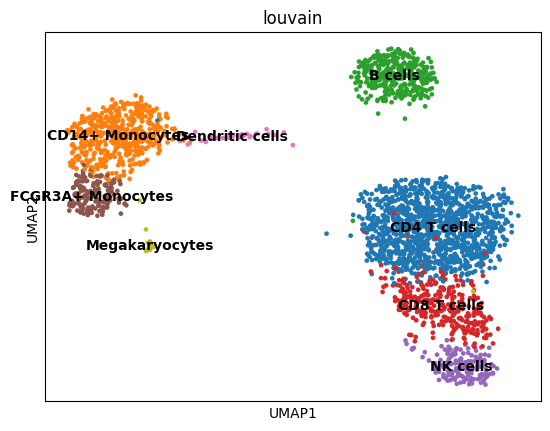

In [5]:
import scanpy as sc
import pandas as pd

# Download the classic PBMC3k dataset
adata = sc.datasets.pbmc3k_processed()
print(adata)

# This gives you a pre-processed dataset with:
# - 2,638 cells × 1,838 genes
# - UMAP, PCA, and clustering already computed
# - Cell type annotations

# Basic exploration
print("Cell types:")
print(adata.obs['louvain'].value_counts())

# Quick UMAP plot
sc.pl.umap(adata, color='louvain', legend_loc='on data')

In [6]:
# Install R essentials and rpy2 interface

!apt-get install -y libcurl4-openssl-dev libssl-dev libxml2-dev
!pip install -q rpy2==3.5.11

# Load R magic
%load_ext rpy2.ipython

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libcurl4-openssl-dev is already the newest version (7.81.0-1ubuntu1.20).
libssl-dev is already the newest version (3.0.2-0ubuntu1.19).
libxml2-dev is already the newest version (2.9.13+dfsg-1ubuntu0.7).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.6/216.6 kB 3.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [8]:
%%R
library(Seurat)
library(SeuratData)
library(SeuratDisk)

# Load dataset
SeuratData::InstallData("pbmc3k")
data("pbmc3k")

# Update the Seurat object
pbmc3k <- UpdateSeuratObject(pbmc3k)

# Assign and check
pbmc <- pbmc3k
print(pbmc)

pbmc[["integrated"]] <- NULL
pbmc@reductions$tsne <- NULL
pbmc@reductions$umap <- NULL
pbmc

SaveH5Seurat(pbmc, filename = "pbmc_example.h5Seurat")
Convert("pbmc_example.h5Seurat", dest = "h5ad")

  method            from  
  as.sparse.H5Group Seurat













An object of class Seurat 
13714 features across 2700 samples within 1 assay 
Active assay: RNA (13714 features, 0 variable features)
 2 layers present: counts, data


In [10]:
# write the files to gdrive

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [12]:
!cp pbmc_example.h5ad /content/drive/MyDrive/geneformer_test1/
!cp pbmc_example.h5Seurat /content/drive/MyDrive/geneformer_test1/

**convert data from Anndata to Loom via Anndata.write_loom**

In [13]:
import anndata
adata = anndata.read_h5ad("./pbmc_example.h5ad")

In [14]:
adata.obs

,orig.ident,nCount_RNA,nFeature_RNA,seurat_annotations
AAACATACAACCAC,0,2419.0,779,1
AAACATTGAGCTAC,0,4903.0,1352,3
AAACATTGATCAGC,0,3147.0,1129,1
AAACCGTGCTTCCG,0,2639.0,960,2
AAACCGTGTATGCG,0,980.0,521,6
...,...,...,...,...
TTTCGAACTCTCAT,0,3459.0,1153,2
TTTCTACTGAGGCA,0,3443.0,1224,3
TTTCTACTTCCTCG,0,1684.0,622,3
TTTGCATGAGAGGC,0,1022.0,452,3


In [15]:
adata.var

,features
AL627309.1,AL627309.1
AP006222.2,AP006222.2
RP11-206L10.2,RP11-206L10.2
RP11-206L10.9,RP11-206L10.9
LINC00115,LINC00115
...,...
AC145212.1,AC145212.1
AL592183.1,AL592183.1
AL354822.1,AL354822.1
PNRC2.1,PNRC2.1


In [16]:
adata.var_names

Index(['AL627309.1', 'AP006222.2', 'RP11-206L10.2', 'RP11-206L10.9',
       'LINC00115', 'NOC2L', 'KLHL17', 'PLEKHN1', 'RP11-54O7.17', 'HES4',
       ...
       'MT-ND4L', 'MT-ND4', 'MT-ND5', 'MT-ND6', 'MT-CYB', 'AC145212.1',
       'AL592183.1', 'AL354822.1', 'PNRC2.1', 'SRSF10.1'],
      dtype='object', length=13714)

In [17]:
adata.var.index.values

array(['AL627309.1', 'AP006222.2', 'RP11-206L10.2', ..., 'AL354822.1',
       'PNRC2.1', 'SRSF10.1'], dtype=object)

*Load the gene book, and then compare it with our used genes to get the gene id*

In [19]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [20]:
import pandas as pd
file_path = '/content/gdrive/My Drive/geneformer_data/gene_info_table.csv'
genes = pd.read_csv(file_path)
print(genes.head())

gene_df = genes.drop(columns=["Unnamed: 0"])
print(gene_df.head())

   Unnamed: 0       ensembl_id gene_name       gene_type
0           0  ENSG00000000003    TSPAN6  protein_coding
1           1  ENSG00000000005      TNMD  protein_coding
2           2  ENSG00000000419      DPM1  protein_coding
3           3  ENSG00000000457     SCYL3  protein_coding
4           4  ENSG00000000460  C1orf112  protein_coding
        ensembl_id gene_name       gene_type
0  ENSG00000000003    TSPAN6  protein_coding
1  ENSG00000000005      TNMD  protein_coding
2  ENSG00000000419      DPM1  protein_coding
3  ENSG00000000457     SCYL3  protein_coding
4  ENSG00000000460  C1orf112  protein_coding


**Matching the ENSEMBL ids with the Gene Symbols : code 1**

In [23]:
import pandas as pd
import numpy as np

# Load and clean the gene mapping file
genes = pd.read_csv(file_path)
print(genes.head())

gene_df = genes.drop(columns=["Unnamed: 0"])
print(gene_df.head())

# Step 1: Create a mapping dictionary from gene_name to ensembl_id
gene_to_ensembl = dict(zip(gene_df['gene_name'], gene_df['ensembl_id']))

# Step 2: Get current gene names from your AnnData
current_genes = adata.var.index.tolist()

# Step 3: Find which genes can be mapped
mappable_genes = []
ensembl_ids = []
gene_indices = []

for i, gene in enumerate(current_genes):
    if gene in gene_to_ensembl:
        mappable_genes.append(gene)
        # Remove version number if present (e.g., ENSG00000000003.15 -> ENSG00000000003)
        ensembl_id = gene_to_ensembl[gene].split('.')[0]
        ensembl_ids.append(ensembl_id)
        gene_indices.append(i)

print(f"Found {len(mappable_genes)} genes with Ensembl mappings out of {len(current_genes)} total genes")

# Step 4: Create filtered AnnData with only mappable genes
adata_filtered = adata[:, gene_indices]

# Step 5: Replace gene names with Ensembl IDs
adata_filtered.var.index = ensembl_ids

# Optional: Keep original gene names as a column for reference
adata_filtered.var['gene_name'] = mappable_genes

# Step 6: Add n_counts for Geneformer compatibility
adata_filtered.obs["n_counts"] = np.array(adata_filtered.X.sum(axis=1)).flatten()

print(f"Final AnnData: {adata_filtered.n_obs} cells × {adata_filtered.n_vars} genes")
print("Sample gene IDs:", adata_filtered.var.index[:5].tolist())

# Your AnnData now has Ensembl IDs as gene identifiers
adata_final = adata_filtered

# Write into loom format (next)
# adata_final.write_loom("pbms.option1.loom")
# print("Saved to: pbms.option1.loom")

# Verify Geneformer compatibility
print("\nGeneformer compatibility check:")
print(f"✓ Has n_counts: {'n_counts' in adata_final.obs.columns}")
print(f"✓ Gene format: {adata_final.var.index[0]} (Ensembl ID)")
print(f"✓ File saved as Loom format")

   Unnamed: 0       ensembl_id gene_name       gene_type
0           0  ENSG00000000003    TSPAN6  protein_coding
1           1  ENSG00000000005      TNMD  protein_coding
2           2  ENSG00000000419      DPM1  protein_coding
3           3  ENSG00000000457     SCYL3  protein_coding
4           4  ENSG00000000460  C1orf112  protein_coding
        ensembl_id gene_name       gene_type
0  ENSG00000000003    TSPAN6  protein_coding
1  ENSG00000000005      TNMD  protein_coding
2  ENSG00000000419      DPM1  protein_coding
3  ENSG00000000457     SCYL3  protein_coding
4  ENSG00000000460  C1orf112  protein_coding
Found 13645 genes with Ensembl mappings out of 13714 total genes
Final AnnData: 2700 cells × 13645 genes
Sample gene IDs: ['ENSG00000237683', 'ENSG00000228463', 'ENSG00000228327', 'ENSG00000237491', 'ENSG00000225880']


/tmp/ipython-input-23-990991524.py:36: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  adata_filtered.var.index = ensembl_ids


Saved to: pbms.option1.loom

Geneformer compatibility check:
✓ Has n_counts: True
✓ Gene format: ENSG00000237683 (Ensembl ID)
✓ File saved as Loom format


In [29]:
# List all available metadata columns
adata_final.obs.columns.tolist()
# Show the first 5 rows of cell metadata
adata_final.obs.head()

,orig.ident,nCount_RNA,nFeature_RNA,seurat_annotations,n_counts
AAACATACAACCAC,0,2419.0,779,1,2419.0
AAACATTGAGCTAC,0,4903.0,1352,3,4900.0
AAACATTGATCAGC,0,3147.0,1129,1,3147.0
AAACCGTGCTTCCG,0,2639.0,960,2,2639.0
AAACCGTGTATGCG,0,980.0,521,6,980.0


In [30]:
# List all available metadata columns
adata_final.var.columns.tolist()
# Show the first 5 rows of cell metadata
adata_final.var.head()

,features,gene_name
ENSG00000237683,AL627309.1,AL627309.1
ENSG00000228463,AP006222.2,AP006222.2
ENSG00000228327,RP11-206L10.2,RP11-206L10.2
ENSG00000237491,RP11-206L10.9,RP11-206L10.9
ENSG00000225880,LINC00115,LINC00115


In [31]:
adata_final.obs["cell_type"] = adata.obs["seurat_annotations"]
adata_final.obs["organ_major"] = adata.obs["seurat_annotations"]
adata_final.obs["organ"] = adata.obs["seurat_annotations"]

# Display the first few rows and all columns of the observation metadata
print("Observation (Cell) Metadata (adata_final.obs.head()):")
print(adata_final.obs.head())

# Print all column names available in the observation metadata
print("\nColumns in Observation (Cell) Metadata:")
print(adata_final.obs.columns.tolist())

# You can also get a summary of a specific numerical column, e.g., 'n_counts'
# if 'n_counts' in adata_final.obs.columns:
#     print("\nSummary of 'n_counts' column:")
#     print(adata_final.obs['n_counts'].describe())

# Display the first few rows and all columns of the variable metadata
print("Variable (Gene) Metadata (adata_final.var.head()):")
print(adata_final.var.head())

# Print all column names available in the variable metadata
print("\nColumns in Variable (Gene) Metadata:")
print(adata_final.var.columns.tolist())

# Verify the gene identifiers (the index of adata_final.var)
print("\nGene Identifiers (adata_final.var.index[:5].tolist()):")
print(adata_final.var.index[:5].tolist())

# Check the total number of genes (variables)
print(f"\nTotal number of genes in adata_final: {adata_final.n_vars}")

Observation (Cell) Metadata (adata_final.obs.head()):
                orig.ident  nCount_RNA  nFeature_RNA  seurat_annotations  \
AAACATACAACCAC           0      2419.0           779                   1   
AAACATTGAGCTAC           0      4903.0          1352                   3   
AAACATTGATCAGC           0      3147.0          1129                   1   
AAACCGTGCTTCCG           0      2639.0           960                   2   
AAACCGTGTATGCG           0       980.0           521                   6   

                n_counts  cell_type  organ_major  organ  
AAACATACAACCAC    2419.0          1            1      1  
AAACATTGAGCTAC    4900.0          3            3      3  
AAACATTGATCAGC    3147.0          1            1      1  
AAACCGTGCTTCCG    2639.0          2            2      2  
AAACCGTGTATGCG     980.0          6            6      6  

Columns in Observation (Cell) Metadata:
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'seurat_annotations', 'n_counts', 'cell_type', 'organ_m

In [49]:
from google.colab import drive
drive.mount('/content/drive')

# Write into loom format on gdrive
adata_final.write_loom("pbms.option1.loom")
print("Saved to: pbms.option1.loom")

# Define full path to your desired location in Google Drive
output_path = "/content/drive/My Drive/geneformer_test1/pbms.option1.loom"

# Save the AnnData object in Loom format
adata_final.write_loom(output_path)
print(f"Saved to: {output_path}")

# Verify Geneformer compatibility
print("\nGeneformer compatibility check:")
print(f"✓ Has n_counts: {'n_counts' in adata_final.obs.columns}")
print(f"✓ Gene format: {adata_final.var.index[0]} (Ensembl ID)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to: pbms.option1.loom
Saved to: /content/drive/My Drive/geneformer_test1/pbms.option1.loom

Geneformer compatibility check:
✓ Has n_counts: True
✓ Gene format: ENSG00000237683 (Ensembl ID)


In [50]:
adata_final.var_names

Index(['ENSG00000237683', 'ENSG00000228463', 'ENSG00000228327',
       'ENSG00000237491', 'ENSG00000225880', 'ENSG00000188976',
       'ENSG00000187961', 'ENSG00000187583', 'ENSG00000272512',
       'ENSG00000188290',
       ...
       'ENSG00000212907', 'ENSG00000198886', 'ENSG00000198786',
       'ENSG00000198695', 'ENSG00000198727', 'ENSG00000215750',
       'ENSG00000273748', 'ENSG00000278384', 'ENSGunknown_PNRC2_1',
       'ENSGunknown_SRSF10_1'],
      dtype='object', length=13645)

**Matching the ENSEMBL ids with the Gene Symbols : code 2**

In [51]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np

file_path="/content/drive/My Drive/geneformer_test1/gene_info_table.csv"
genes = pd.read_csv(file_path)
print(genes.head())

gene_df = genes.drop(columns=["Unnamed: 0"])
print(gene_df.head())

# Create mapping and filter to only keep mappable genes
gene_to_ensembl = dict(zip(gene_df['gene_name'], gene_df['ensembl_id']))

# Find mappable genes
mappable_mask = adata.var.index.isin(gene_df['gene_name'])
adata_mapped = adata[:, mappable_mask]

# Get Ensembl IDs for the remaining genes
ensembl_ids = [gene_to_ensembl[gene].split('.')[0] for gene in adata_mapped.var.index]

# Update gene identifiers
adata_mapped.var.index = ensembl_ids
adata_mapped.var['ensembl_id'] = ensembl_ids

# Add required metadata for Geneformer
adata_mapped.obs['n_counts'] = np.array(adata_mapped.X.sum(axis=1)).flatten()

print(f"Final dataset ready for Geneformer: {adata_mapped.n_obs} cells × {adata_mapped.n_vars} genes")

# Save for Geneformer
adata_mapped.write_loom("pbms.option2.loom")
print("Saved to: pbms.option2.loom")

# Optional: Verification
print("\nGeneformer compatibility check:")
print(f"✓ Has n_counts: {'n_counts' in adata_mapped.obs.columns}")
print(f"✓ Gene format: {adata_mapped.var.index[0]} (should be ENSG...)")
print(f"✓ Data shape: {adata_mapped.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Unnamed: 0       ensembl_id gene_name       gene_type
0           0  ENSG00000000003    TSPAN6  protein_coding
1           1  ENSG00000000005      TNMD  protein_coding
2           2  ENSG00000000419      DPM1  protein_coding
3           3  ENSG00000000457     SCYL3  protein_coding
4           4  ENSG00000000460  C1orf112  protein_coding
        ensembl_id gene_name       gene_type
0  ENSG00000000003    TSPAN6  protein_coding
1  ENSG00000000005      TNMD  protein_coding
2  ENSG00000000419      DPM1  protein_coding
3  ENSG00000000457     SCYL3  protein_coding
4  ENSG00000000460  C1orf112  protein_coding
Final dataset ready for Geneformer: 2700 cells × 13645 genes


/tmp/ipython-input-51-2716873812.py:25: ImplicitModificationWarning: Trying to modify index of attribute `.var` of view, initializing view as actual.
  adata_mapped.var.index = ensembl_ids


Saved to: pbms.option2.loom

Geneformer compatibility check:
✓ Has n_counts: True
✓ Gene format: ENSG00000237683 (should be ENSG...)
✓ Data shape: (2700, 13645)


In [52]:
# Define full path to your desired location in Google Drive
output_path = "/content/drive/My Drive/geneformer_test1/pbms.option2.loom"

# Save the AnnData object in Loom format
adata_mapped.write_loom(output_path)
print(f"Saved to: {output_path}")

Saved to: /content/drive/My Drive/geneformer_test1/pbms.option2.loom


In [53]:
# Display the first few rows and all columns of the observation metadata
print("Observation (Cell) Metadata (adata_mapped.obs.head()):")
print(adata_mapped.obs.head())

# Print all column names available in the observation metadata
print("\nColumns in Observation (Cell) Metadata:")
print(adata_mapped.obs.columns.tolist())

# You can also get a summary of a specific numerical column, e.g., 'n_counts'
# if 'n_counts' in adata_mapped.obs.columns:
#     print("\nSummary of 'n_counts' column:")
#     print(adata_mapped.obs['n_counts'].describe())

# Display the first few rows and all columns of the variable metadata
print("Variable (Gene) Metadata (adata_mapped.var.head()):")
print(adata_mapped.var.head())

# Print all column names available in the variable metadata
print("\nColumns in Variable (Gene) Metadata:")
print(adata_mapped.var.columns.tolist())

# Verify the gene identifiers (the index of adata_mapped.var)
print("\nGene Identifiers (adata_mapped.var.index[:5].tolist()):")
print(adata_mapped.var.index[:5].tolist())

# Check the total number of genes (variables)
print(f"\nTotal number of genes in adata_mapped: {adata_mapped.n_vars}")

Observation (Cell) Metadata (adata_mapped.obs.head()):
                orig.ident  nCount_RNA  nFeature_RNA  seurat_annotations  \
AAACATACAACCAC           0      2419.0           779                   1   
AAACATTGAGCTAC           0      4903.0          1352                   3   
AAACATTGATCAGC           0      3147.0          1129                   1   
AAACCGTGCTTCCG           0      2639.0           960                   2   
AAACCGTGTATGCG           0       980.0           521                   6   

                n_counts  
AAACATACAACCAC    2419.0  
AAACATTGAGCTAC    4900.0  
AAACATTGATCAGC    3147.0  
AAACCGTGCTTCCG    2639.0  
AAACCGTGTATGCG     980.0  

Columns in Observation (Cell) Metadata:
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'seurat_annotations', 'n_counts']
Variable (Gene) Metadata (adata_mapped.var.head()):
                      features       ensembl_id
ENSG00000237683     AL627309.1  ENSG00000237683
ENSG00000228463     AP006222.2  ENSG00000228463
ENSG000002

**Matching the ENSEMBL ids with the Gene Symbols : code 3**

In [54]:
import pandas as pd
import anndata as ad

genes = pd.read_csv(file_path)
print(genes.head())

gene_df = genes.drop(columns=["Unnamed: 0"])
print(gene_df.head())

# Step 1: Make sure gene_df is indexed by gene_name
gene_df = gene_df.set_index("gene_name")

# Step 2: Filter to genes that exist in gene_df
common_genes = [gene for gene in adata.var_names if gene in gene_df.index]

# Step 3: Get the corresponding Ensembl IDs
ensembl_ids = [gene_df.loc[gene, "ensembl_id"] for gene in common_genes]

# Step 4: Subset the AnnData object to only those genes
adata_cut = adata[:, [gene in common_genes for gene in adata.var_names]]

# Step 5: Replace gene names with Ensembl IDs
adata_cut.var_names = ensembl_ids

# Optional: Add ensembl_id as a column for clarity
adata_cut.var["ensembl_id"] = adata_cut.var_names

# Step 6: Add n_counts for Geneformer compatibility
adata_cut.obs["n_counts"] = np.array(adata_cut.X.sum(axis=1)).flatten()

# Optional: Also add n_genes (number of expressed genes per cell)
adata_cut.obs["n_genes"] = np.array((adata_cut.X > 0).sum(axis=1)).flatten()

# Verify the results
print(f"Final dataset: {adata_cut.n_obs} cells × {adata_cut.n_vars} genes")
print(f"Found {len(common_genes)} genes with Ensembl mappings")
print("n_counts summary:")
print(adata_cut.obs["n_counts"].describe())

   Unnamed: 0       ensembl_id gene_name       gene_type
0           0  ENSG00000000003    TSPAN6  protein_coding
1           1  ENSG00000000005      TNMD  protein_coding
2           2  ENSG00000000419      DPM1  protein_coding
3           3  ENSG00000000457     SCYL3  protein_coding
4           4  ENSG00000000460  C1orf112  protein_coding
        ensembl_id gene_name       gene_type
0  ENSG00000000003    TSPAN6  protein_coding
1  ENSG00000000005      TNMD  protein_coding
2  ENSG00000000419      DPM1  protein_coding
3  ENSG00000000457     SCYL3  protein_coding
4  ENSG00000000460  C1orf112  protein_coding
Final dataset: 2700 cells × 13645 genes
Found 13645 genes with Ensembl mappings
n_counts summary:
count     2700.000000
mean      2364.708889
std       1093.114813
min        545.000000
25%       1755.750000
50%       2195.500000
75%       2762.000000
max      15815.000000
Name: n_counts, dtype: float64


/usr/local/lib/python3.11/dist-packages/anndata/_core/anndata.py:835: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['ENSG00000237683', 'ENSG00000228463', 'ENSG00000228327', 'ENSG00000237491', 'ENSG00000225880']

    Inferred to be: mixed

  names = self._prep_dim_index(names, "var")


In [55]:
import pandas as pd
import anndata as ad
import numpy as np

genes = pd.read_csv(file_path)
print(genes.head())

gene_df = genes.drop(columns=["Unnamed: 0"])
print(gene_df.head())

# Step 1: Make sure gene_df is indexed by gene_name
gene_df = gene_df.set_index("gene_name")

# Step 2: Filter to genes that exist in gene_df
common_genes = [gene for gene in adata.var_names if gene in gene_df.index]

# Step 3: Get the corresponding Ensembl IDs and CLEAN them
ensembl_ids = []
clean_common_genes = []

for gene in common_genes:
    ensembl_id = str(gene_df.loc[gene, "ensembl_id"]).split('.')[0]  # Convert to string and remove version

    # Only keep properly formatted Ensembl IDs
    if ensembl_id.startswith('ENSG') and len(ensembl_id) >= 15:
        ensembl_ids.append(ensembl_id)
        clean_common_genes.append(gene)
    else:
        print(f"Skipping malformed ID: {ensembl_id} for gene {gene}")

print(f"Kept {len(ensembl_ids)} genes with valid Ensembl IDs")

# Step 4: Subset the AnnData object to only those genes
adata_cut = adata[:, [gene in clean_common_genes for gene in adata.var_names]]

# Step 5: Replace gene names with clean Ensembl IDs
adata_cut.var_names = ensembl_ids

# Step 6: Clean the var DataFrame to ensure all columns are consistent
adata_cut.var = pd.DataFrame(index=adata_cut.var_names)
adata_cut.var["ensembl_id"] = adata_cut.var_names  # Add as string column

# Step 7: Add n_counts for Geneformer compatibility
adata_cut.obs["n_counts"] = np.array(adata_cut.X.sum(axis=1)).flatten()
adata_cut.obs["n_genes"] = np.array((adata_cut.X > 0).sum(axis=1)).flatten()

# Step 8: Ensure all data types are consistent
print("Data types check:")
print(adata_cut.var.dtypes)
print(adata_cut.obs.dtypes)

# Verify the results
print(f"Final dataset: {adata_cut.n_obs} cells × {adata_cut.n_vars} genes")
print(f"Sample Ensembl IDs: {adata_cut.var_names[:3].tolist()}")

# Save for Geneformer
try:
    adata_cut.write_loom("pbms.option3.loom")
    print("Saved to: pbms.option3.loom")
except Exception as e:
    print(f"Error saving: {e}")
    # Alternative: save as h5ad first to debug
    adata_cut.write_h5ad("pbms.option3.h5ad")
    print("Saved as h5ad for debugging")

   Unnamed: 0       ensembl_id gene_name       gene_type
0           0  ENSG00000000003    TSPAN6  protein_coding
1           1  ENSG00000000005      TNMD  protein_coding
2           2  ENSG00000000419      DPM1  protein_coding
3           3  ENSG00000000457     SCYL3  protein_coding
4           4  ENSG00000000460  C1orf112  protein_coding
        ensembl_id gene_name       gene_type
0  ENSG00000000003    TSPAN6  protein_coding
1  ENSG00000000005      TNMD  protein_coding
2  ENSG00000000419      DPM1  protein_coding
3  ENSG00000000457     SCYL3  protein_coding
4  ENSG00000000460  C1orf112  protein_coding
Skipping malformed ID: gene_name
CPSF3L       ENSG00000127054
CPSF3L    ENSGunknown_CPSF3L
Name: ensembl_id, dtype: object for gene CPSF3L
Skipping malformed ID: gene_name
C1orf233         ENSG00000228594
C1orf233    ENSGunknown_C1orf233
Name: ensembl_id, dtype: object for gene C1orf233
Skipping malformed ID: gene_name
TP73-AS1    ENSG00000227372
TP73-AS1    ENSG00000276189
Name: ensem

In [56]:
# Display the first few rows and all columns of the observation metadata
print("Observation (Cell) Metadata (adata_cut.obs.head()):")
print(adata_cut.obs.head())

# Print all column names available in the observation metadata
print("\nColumns in Observation (Cell) Metadata:")
print(adata_cut.obs.columns.tolist())

# You can also get a summary of a specific numerical column, e.g., 'n_counts'
# if 'n_counts' in adata_cut.obs.columns:
#     print("\nSummary of 'n_counts' column:")
#     print(adata_cut.obs['n_counts'].describe())

# Display the first few rows and all columns of the variable metadata
print("Variable (Gene) Metadata (adata_cut.var.head()):")
print(adata_cut.var.head())

# Print all column names available in the variable metadata
print("\nColumns in Variable (Gene) Metadata:")
print(adata.var.columns.tolist()) # Using adata.var.columns to see original columns

# Verify the gene identifiers (the index of adata_cut.var)
print("\nGene Identifiers (adata_cut.var.index[:5].tolist()):")
print(adata_cut.var.index[:5].tolist())

# Check the total number of genes (variables)
print(f"\nTotal number of genes in adata_cut: {adata_cut.n_vars}")

Observation (Cell) Metadata (adata_cut.obs.head()):
                orig.ident  nCount_RNA  nFeature_RNA  seurat_annotations  \
AAACATACAACCAC           0      2419.0           779                   1   
AAACATTGAGCTAC           0      4903.0          1352                   3   
AAACATTGATCAGC           0      3147.0          1129                   1   
AAACCGTGCTTCCG           0      2639.0           960                   2   
AAACCGTGTATGCG           0       980.0           521                   6   

                n_counts  n_genes  
AAACATACAACCAC    2158.0      723  
AAACATTGAGCTAC    4247.0     1255  
AAACATTGATCAGC    2740.0     1059  
AAACCGTGCTTCCG    2372.0      879  
AAACCGTGTATGCG     880.0      479  

Columns in Observation (Cell) Metadata:
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'seurat_annotations', 'n_counts', 'n_genes']
Variable (Gene) Metadata (adata_cut.var.head()):
                      ensembl_id
ENSG00000237683  ENSG00000237683
ENSG00000228463  ENSG00000228

In [58]:
# Define full path to your desired location in Google Drive
output_path = "/content/drive/My Drive/geneformer_test1/pbms.option3.loom"

# Save the AnnData object in Loom format
adata_cut.write_loom(output_path)
print(f"Saved to: {output_path}")

Saved to: /content/drive/My Drive/geneformer_test1/pbms.option3.loom


loom file structure:

├── matrix/          # Main expression data (genes × cells)

├── row_attrs/       # Gene metadata (gene names, IDs, etc.)

├── col_attrs/       # Cell metadata (cell types, conditions, etc.)

├── row_graphs/      # Optional: gene-gene relationships

├── col_graphs/      # Optional: cell-cell relationships

└── layers/          # Optional: additional data layers

In [59]:
# Observation Metadata (Cells) 🔬
# The adata_final.obs DataFrame contains all the cell-specific annotations.
# You can inspect its structure and content using common Pandas methods.

# This output will show you columns like orig.ident, nCount_RNA, nFeature_RNA, percent.mt,
# and the n_counts and n_genes columns you added for Geneformer compatibility.

# Display the first few rows and all columns of the observation metadata
print("Observation (Cell) Metadata (adata_final.obs.head()):")
print(adata_final.obs.head())

# Print all column names available in the observation metadata
print("\nColumns in Observation (Cell) Metadata:")
print(adata_final.obs.columns.tolist())

# You can also get a summary of a specific numerical column, e.g., 'n_counts'
# if 'n_counts' in adata_final.obs.columns:
#     print("\nSummary of 'n_counts' column:")
#     print(adata_final.obs['n_counts'].describe())

Observation (Cell) Metadata (adata_final.obs.head()):
                orig.ident  nCount_RNA  nFeature_RNA  seurat_annotations  \
AAACATACAACCAC           0      2419.0           779                   1   
AAACATTGAGCTAC           0      4903.0          1352                   3   
AAACATTGATCAGC           0      3147.0          1129                   1   
AAACCGTGCTTCCG           0      2639.0           960                   2   
AAACCGTGTATGCG           0       980.0           521                   6   

                n_counts  cell_type  organ_major  organ  
AAACATACAACCAC    2419.0          1            1      1  
AAACATTGAGCTAC    4900.0          3            3      3  
AAACATTGATCAGC    3147.0          1            1      1  
AAACCGTGCTTCCG    2639.0          2            2      2  
AAACCGTGTATGCG     980.0          6            6      6  

Columns in Observation (Cell) Metadata:
['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'seurat_annotations', 'n_counts', 'cell_type', 'organ_m

In [60]:
# Variable Metadata (Genes) 🧬

# The adata_final.var DataFrame holds the gene-specific annotations.
# This is where you'd expect to see the Ensembl IDs as the primary identifiers (index)
# and potentially original gene symbols or other gene-related information as columns.

# Display the first few rows and all columns of the variable metadata
print("Variable (Gene) Metadata (adata_final.var.head()):")
print(adata_final.var.head())

# Print all column names available in the variable metadata
print("\nColumns in Variable (Gene) Metadata:")
print(adata_final.var.columns.tolist())

# Verify the gene identifiers (the index of adata_final.var)
print("\nGene Identifiers (adata_final.var.index[:5].tolist()):")
print(adata_final.var.index[:5].tolist())

# Check the total number of genes (variables)
print(f"\nTotal number of genes in adata_final: {adata_final.n_vars}")

# Add 'ensembl_id' as a new column to adata_final.var
# The values for this column will be taken directly from the current index of .var
adata_final.var['ensembl_id'] = adata_final.var.index.values

# Now, verify that the 'ensembl_id' column has been added
print("Variable (Gene) Metadata with 'ensembl_id' column (adata_final.var.head()):")
print(adata_final.var.head())

# Exclude the genes that contain the particle "unknown"

print("Original adata_final shape:", adata_final.shape)
print("Original adata_final.var.index[:5].tolist():", adata_final.var.index[:5].tolist())

# Create a boolean mask: True for IDs that DO NOT contain "unknown"
# We check the .var.index directly
genes_to_keep_mask = ~adata_final.var.index.str.contains("unknown", case=False, na=False)

# Filter the AnnData object using the mask
adata_filtered_unknown = adata_final[:, genes_to_keep_mask].copy()

print("\nFiltered adata_final shape (removed 'unknown' genes):", adata_filtered_unknown.shape)
print("Filtered adata_final.var.index[:5].tolist():", adata_filtered_unknown.var.index[:5].tolist())

# Optional: Verify that 'unknown' is no longer present in the index
# This might take a moment for very large datasets
# assert not any("unknown" in s for s in adata_filtered_unknown.var.index.tolist()), "Error: 'unknown' found in index after filtering!"
print("\nSuccessfully filtered out genes with 'unknown' in their Ensembl ID.")

adata_final = adata_filtered_unknown

# Verify the gene identifiers (the index of adata_final.var)
print("\nGene Identifiers (adata_final.var.index[:5].tolist()):")
print(adata_final.var.index[:5].tolist())

# Check the total number of genes (variables)
print(f"\nTotal number of genes in adata_final: {adata_final.n_vars}")

Variable (Gene) Metadata (adata_final.var.head()):
                      features      gene_name
ENSG00000237683     AL627309.1     AL627309.1
ENSG00000228463     AP006222.2     AP006222.2
ENSG00000228327  RP11-206L10.2  RP11-206L10.2
ENSG00000237491  RP11-206L10.9  RP11-206L10.9
ENSG00000225880      LINC00115      LINC00115

Columns in Variable (Gene) Metadata:
['features', 'gene_name']

Gene Identifiers (adata_final.var.index[:5].tolist()):
['ENSG00000237683', 'ENSG00000228463', 'ENSG00000228327', 'ENSG00000237491', 'ENSG00000225880']

Total number of genes in adata_final: 13645
Variable (Gene) Metadata with 'ensembl_id' column (adata_final.var.head()):
                      features      gene_name       ensembl_id
ENSG00000237683     AL627309.1     AL627309.1  ENSG00000237683
ENSG00000228463     AP006222.2     AP006222.2  ENSG00000228463
ENSG00000228327  RP11-206L10.2  RP11-206L10.2  ENSG00000228327
ENSG00000237491  RP11-206L10.9  RP11-206L10.9  ENSG00000237491
ENSG00000225880      


**To use adata_final for the next steps**

Tokenizing .loom single cell RNA-seq data to rank value encoding .dataset format.

**Input data** is a directory with .loom files containing raw counts from single cell RNAseq data, including all genes detected in the transcriptome without feature selection.

**Genes** should be labeled with **Ensembl IDs (row attribute "ensembl_id")**, which provide a unique identifer for conversion to tokens. Other forms of gene annotations (e.g. gene names) can be converted to Ensembl IDs via Ensembl Biomart. Cells should be labeled with the total read count in the cell (column attribute "n_counts") to be used for normalization.

**No cell metadata** is required, but custom cell attributes may be passed onto the tokenized dataset by providing a dictionary of custom attributes to be added, which is formatted as loom_col_attr_name : desired_dataset_col_attr_name.

*For example, if the original .loom dataset has column attributes "cell_type" and "organ_major" and one would like to retain these attributes as labels in the tokenized dataset with the new names "cell_type" and "organ", respectively, the following custom attribute dictionary should be provided: {"cell_type": "cell_type", "organ_major": "organ"}.*

Additionally, if the original .loom file contains a cell column attribute called **"filter_pass",** this column will be used as a binary indicator of whether to include these cells in the tokenized data. All cells with "1" in this attribute will be tokenized, whereas the others will be excluded. One may use this column to indicate QC filtering or other criteria for selection for inclusion in the final tokenized dataset.

If one's data is in other formats besides .loom, one can use the relevant tools (such as Anndata tools) to convert the file to a .loom format prior to running the transcriptome tokenizer.

In [61]:
import pandas as pd

print("=== VARIABLE (GENE) METADATA ===")
print(f"Number of genes: {adata_final.n_vars}")
print(f"Gene index name: {adata_final.var.index.name}")
print("\nVariable DataFrame:")
print(adata_final.var.head())
print(f"\nVariable columns: {list(adata_final.var.columns)}")
print(f"Variable dtypes:\n{adata_final.var.dtypes}")

print("\n" + "="*50)

print("=== OBSERVATION (CELL) METADATA ===")
print(f"Number of cells: {adata_final.n_obs}")
print(f"Cell index name: {adata_final.obs.index.name}")
print("\nObservation DataFrame:")
print(adata_final.obs.head())
print(f"\nObservation columns: {list(adata_final.obs.columns)}")
print(f"Observation dtypes:\n{adata_final.obs.dtypes}")

print("\n" + "="*50)

=== VARIABLE (GENE) METADATA ===
Number of genes: 12916
Gene index name: None

Variable DataFrame:
                      features      gene_name       ensembl_id
ENSG00000237683     AL627309.1     AL627309.1  ENSG00000237683
ENSG00000228463     AP006222.2     AP006222.2  ENSG00000228463
ENSG00000228327  RP11-206L10.2  RP11-206L10.2  ENSG00000228327
ENSG00000237491  RP11-206L10.9  RP11-206L10.9  ENSG00000237491
ENSG00000225880      LINC00115      LINC00115  ENSG00000225880

Variable columns: ['features', 'gene_name', 'ensembl_id']
Variable dtypes:
features      object
gene_name     object
ensembl_id    object
dtype: object

=== OBSERVATION (CELL) METADATA ===
Number of cells: 2700
Cell index name: None

Observation DataFrame:
                orig.ident  nCount_RNA  nFeature_RNA  seurat_annotations  \
AAACATACAACCAC           0      2419.0           779                   1   
AAACATTGAGCTAC           0      4903.0          1352                   3   
AAACATTGATCAGC           0      3147.

In [62]:
# Show the first few rows of gene metadata
print(adata_final.var.head())

# Show column names (fields) in gene metadata
print("Gene metadata columns:", adata_final.var.columns.tolist())

# Show the first few rows of cell metadata
print(adata_final.obs.head())

# Show column names (fields) in cell metadata
print("Cell metadata columns:", adata_final.obs.columns.tolist())

print(f"AnnData dimensions: {adata_final.n_obs} cells × {adata_final.n_vars} genes")

                      features      gene_name       ensembl_id
ENSG00000237683     AL627309.1     AL627309.1  ENSG00000237683
ENSG00000228463     AP006222.2     AP006222.2  ENSG00000228463
ENSG00000228327  RP11-206L10.2  RP11-206L10.2  ENSG00000228327
ENSG00000237491  RP11-206L10.9  RP11-206L10.9  ENSG00000237491
ENSG00000225880      LINC00115      LINC00115  ENSG00000225880
Gene metadata columns: ['features', 'gene_name', 'ensembl_id']
                orig.ident  nCount_RNA  nFeature_RNA  seurat_annotations  \
AAACATACAACCAC           0      2419.0           779                   1   
AAACATTGAGCTAC           0      4903.0          1352                   3   
AAACATTGATCAGC           0      3147.0          1129                   1   
AAACCGTGCTTCCG           0      2639.0           960                   2   
AAACCGTGTATGCG           0       980.0           521                   6   

                n_counts  cell_type  organ_major  organ  
AAACATACAACCAC    2419.0          1         

In [63]:
# For AnnData objects, use this syntax instead:

ds = adata_final
print(ds.shape)

# For AnnData, use .var and .obs instead of .ra and .ca
print("Variable (gene) metadata columns:", ds.var.columns.tolist())
print("Observation (cell) metadata columns:", ds.obs.columns.tolist())

# Show the actual metadata
print("\nGene metadata:")
print(ds.var.head())

print("\nCell metadata:")
print(ds.obs.head())

# Show expression data (first gene across all cells)
print("\nExpression data for first gene:")
print(ds.X[:, 0])

(2700, 12916)
Variable (gene) metadata columns: ['features', 'gene_name', 'ensembl_id']
Observation (cell) metadata columns: ['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'seurat_annotations', 'n_counts', 'cell_type', 'organ_major', 'organ']

Gene metadata:
                      features      gene_name       ensembl_id
ENSG00000237683     AL627309.1     AL627309.1  ENSG00000237683
ENSG00000228463     AP006222.2     AP006222.2  ENSG00000228463
ENSG00000228327  RP11-206L10.2  RP11-206L10.2  ENSG00000228327
ENSG00000237491  RP11-206L10.9  RP11-206L10.9  ENSG00000237491
ENSG00000225880      LINC00115      LINC00115  ENSG00000225880

Cell metadata:
                orig.ident  nCount_RNA  nFeature_RNA  seurat_annotations  \
AAACATACAACCAC           0      2419.0           779                   1   
AAACATTGAGCTAC           0      4903.0          1352                   3   
AAACATTGATCAGC           0      3147.0          1129                   1   
AAACCGTGCTTCCG           0      2639.0       

In [64]:
# If you want to use Loom syntax, you need to: Read the saved Loom file

import loompy

# Read the Loom file you created
with loompy.connect("/content/pbms.option1.loom") as ds:
    print(ds.shape)
    print("Row attributes (genes):", ds.ra.keys())
    print("Column attributes (cells):", ds.ca.keys())
    print("First gene expression:", ds[:, 0])

(13645, 2700)
Row attributes (genes): ['features', 'gene_name', 'var_names']
Column attributes (cells): ['cell_type', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'obs_names', 'organ', 'organ_major', 'orig.ident', 'seurat_annotations']
First gene expression: [0. 0. 0. ... 0. 0. 0.]


Key Differences:: AnnData <>  Loom

Description ::  adata.var <> ds.ra

Gene/row metadata :: adata.obs <> ds.ca

Cell/column metadata :: adata.X <> ds[:,:]

Expression :: matrixadata.var.columns <> ds.ra.keys()
